# Autoscaling for MongoDB

## Horizontal Scaling by Adding Replicas (CPU Utilization Triggered)

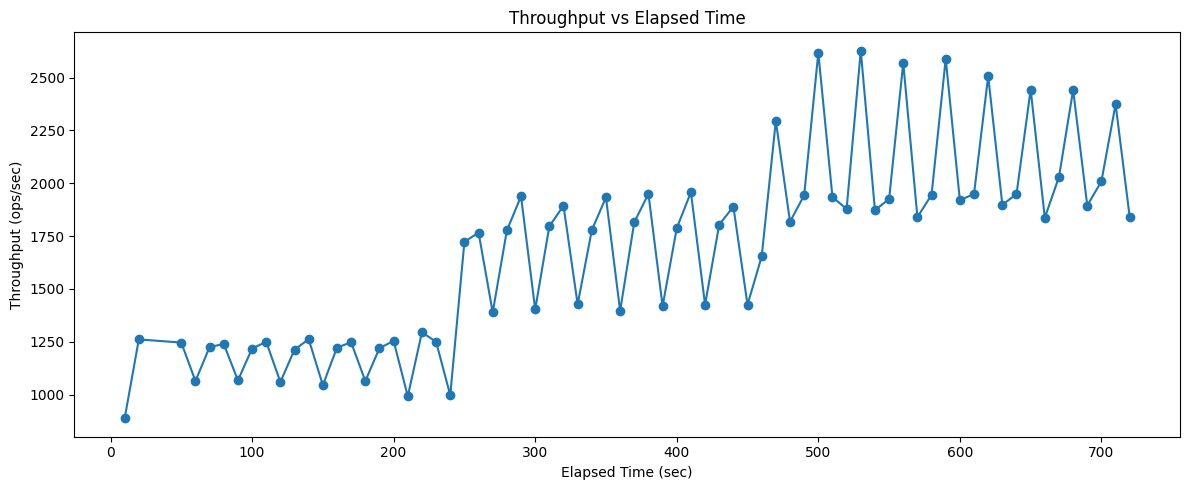

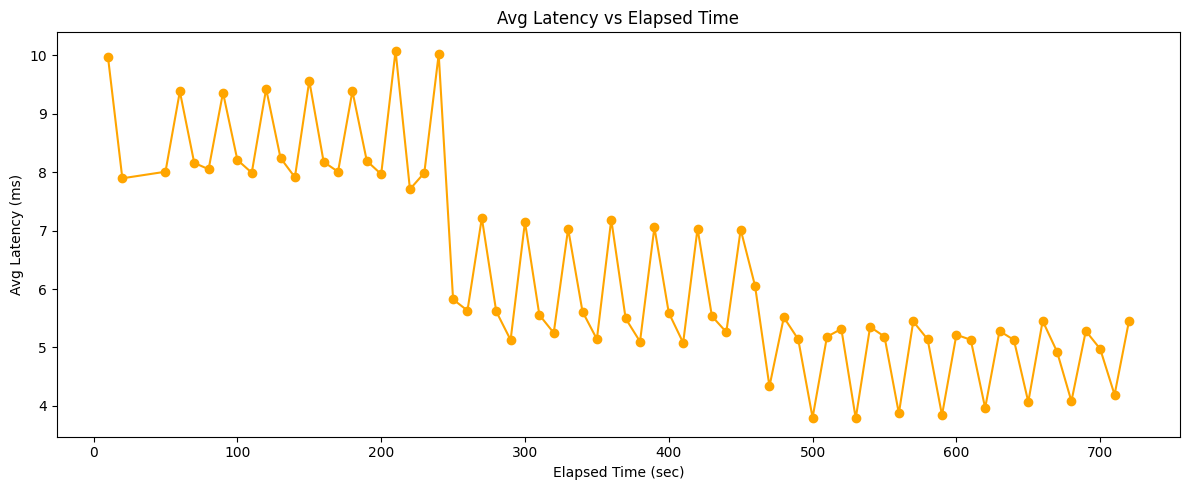

In [15]:
import matplotlib.pyplot as plt
import re

times = []
throughputs = []
latencies = []

with open('cpu_exp/t10_cpu.log') as f:
    for line in f:
        if line.startswith('#OUTLIER'):
            continue
        # Match lines with elapsed sec, ops/sec, and Avg latency
        match = re.search(r'(\d+) sec:.*? ([\d.]+) current ops/sec;.*Avg=([\d.]+)', line)
        if match:
            elapsed_sec = int(match.group(1))
            times.append(elapsed_sec)
            throughputs.append(float(match.group(2)))
            latencies.append(float(match.group(3)) / 1000)

# Plot throughput vs elapsed time
plt.figure(figsize=(12, 5))
plt.plot(times, throughputs, marker='o')
plt.xlabel('Elapsed Time (sec)')
plt.ylabel('Throughput (ops/sec)')
plt.title('Throughput vs Elapsed Time')
plt.tight_layout()
plt.show()

# Plot avg latency vs elapsed time
plt.figure(figsize=(12, 5))
plt.plot(times, latencies, marker='o', color='orange')
plt.xlabel('Elapsed Time (sec)')
plt.ylabel('Avg Latency (ms)')
plt.title('Avg Latency vs Elapsed Time')
plt.tight_layout()
plt.show()

## Horizontal Scaling by Adding Replicas (IOWait Triggered)

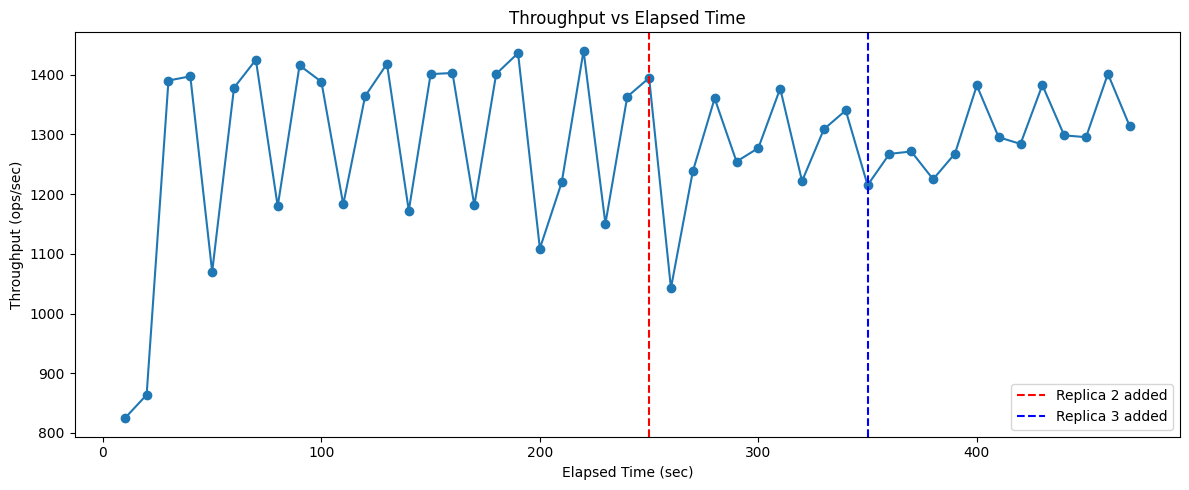

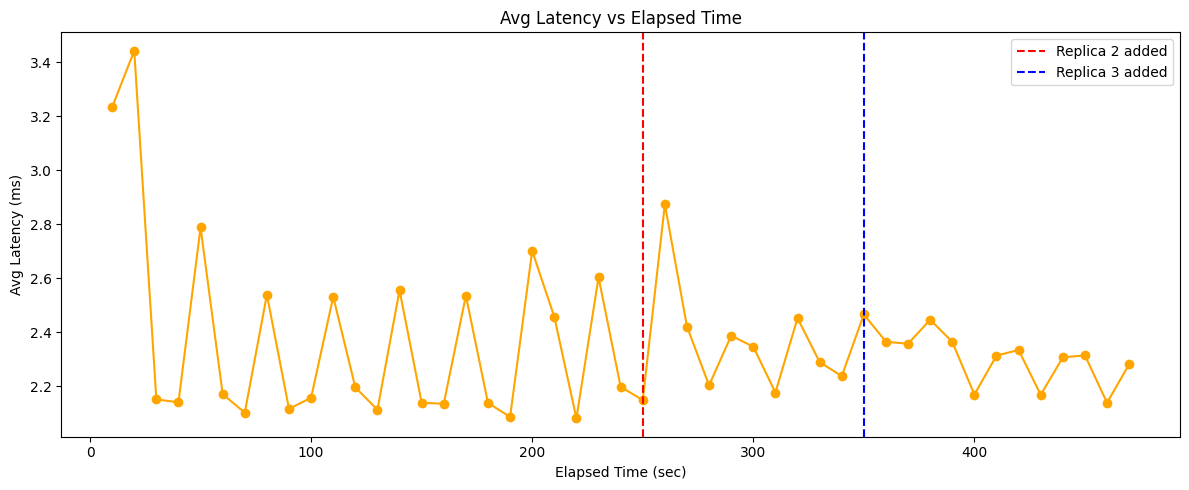

In [16]:
import matplotlib.pyplot as plt
import re

times = []
throughputs = []
latencies = []

with open('iowait_exp/t3_iowait.log') as f:
    for line in f:
        if line.startswith('#OUTLIER'):
            continue
        # Match lines with elapsed sec, ops/sec, and Avg latency
        match = re.search(r'(\d+) sec:.*? ([\d.]+) current ops/sec;.*Avg=([\d.]+)', line)
        if match:
            elapsed_sec = int(match.group(1))
            times.append(elapsed_sec)
            throughputs.append(float(match.group(2)))
            latencies.append(float(match.group(3)) / 1000)

# Plot throughput vs elapsed time
plt.figure(figsize=(12, 5))
plt.plot(times, throughputs, marker='o')
plt.axvline(x=250, color='red', linestyle='--', label='Replica 2 added')
plt.axvline(x=350, color='blue', linestyle='--', label='Replica 3 added')
plt.xlabel('Elapsed Time (sec)')
plt.ylabel('Throughput (ops/sec)')
plt.title('Throughput vs Elapsed Time')
plt.legend()
plt.tight_layout()
plt.show()

# Plot avg latency vs elapsed time
plt.figure(figsize=(12, 5))
plt.plot(times, latencies, marker='o', color='orange')
plt.axvline(x=250, color='red', linestyle='--', label='Replica 2 added')
plt.axvline(x=350, color='blue', linestyle='--', label='Replica 3 added')
plt.xlabel('Elapsed Time (sec)')
plt.ylabel('Avg Latency (ms)')
plt.title('Avg Latency vs Elapsed Time')
plt.legend()
plt.tight_layout()
plt.show()

## Mongos Autoscaler - CPU-bounded

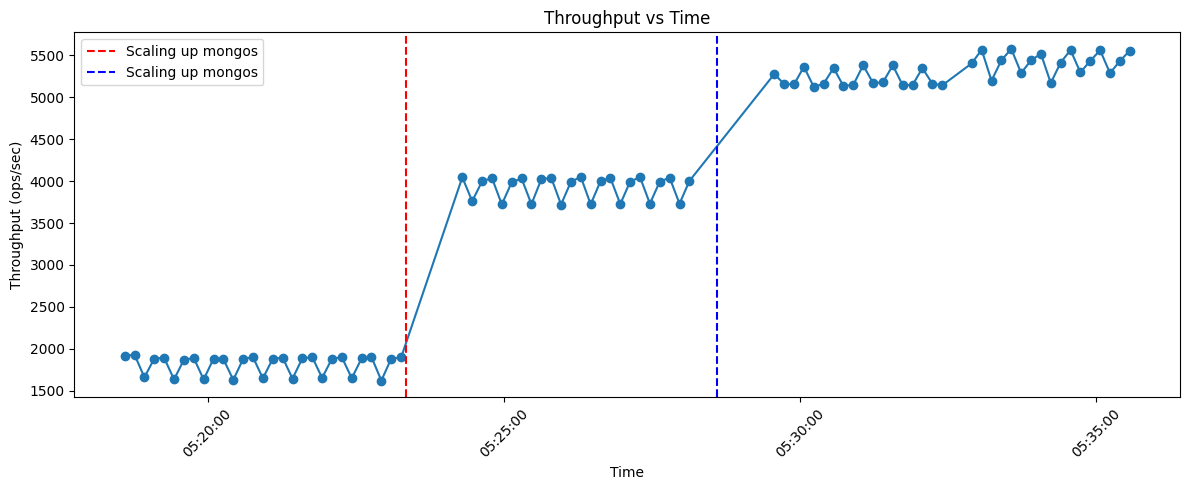

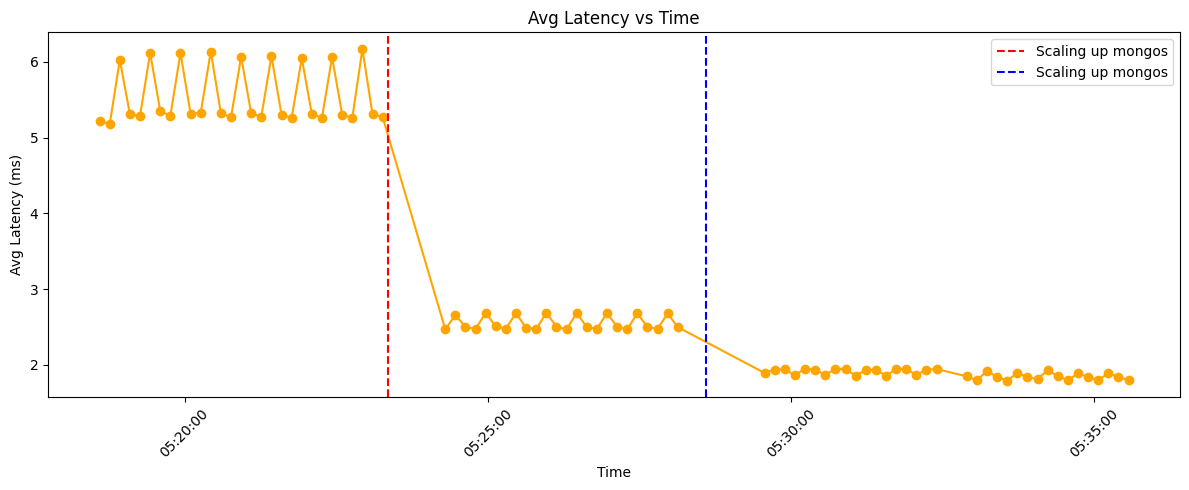

In [17]:
from pathlib import Path
import re
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random

log_dir = Path('mongos_exp')
files = list(log_dir.glob('*.log'))
files.sort()

times = []
throughputs = []
latencies = []

for f in files:
    with f.open() as file:
        for line in file:
            if line.startswith('#OUTLIER'):
                continue
            match = re.search(r' (\d{2}:\d{2}:\d{2}).*? ([\d.]+) current ops/sec;.*Avg=([\d.]+)', line)
            if match:
                times.append(datetime.strptime(match.group(1), '%H:%M:%S'))
                throughputs.append(float(match.group(2)))
                latencies.append(float(match.group(3)) / 1000)

highlight_times = [
    (datetime.strptime('05:23:21', '%H:%M:%S'), "Scaling up mongos", 'red'),
    (datetime.strptime('05:28:36', '%H:%M:%S'), "Scaling up mongos", 'blue'),
]

# Plot throughput vs time
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(times, throughputs, marker='o')
for ht, label, color in highlight_times:
    ax.axvline(x=ht, color=color, linestyle='--', label=label)
ax.set_xlabel('Time')
ax.set_ylabel('Throughput (ops/sec)')
ax.set_title('Throughput vs Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Plot latency vs time
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(times, latencies, marker='o', color='orange')
for ht, label, color in highlight_times:
    ax.axvline(x=ht, color=color, linestyle='--', label=label)
ax.set_xlabel('Time')
ax.set_ylabel('Avg Latency (ms)')
ax.set_title('Avg Latency vs Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Mongod Autoscaler - CPU-bounded

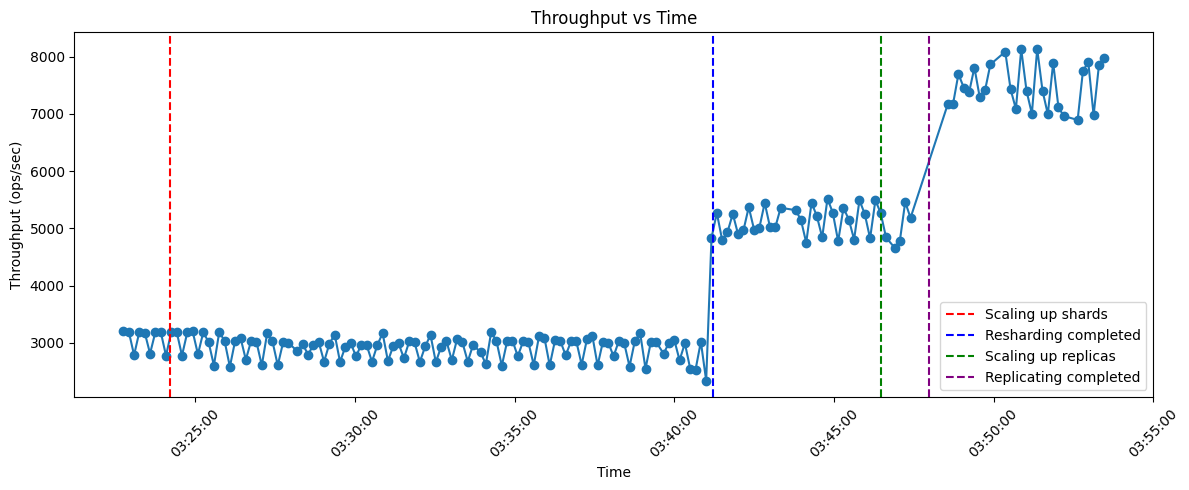

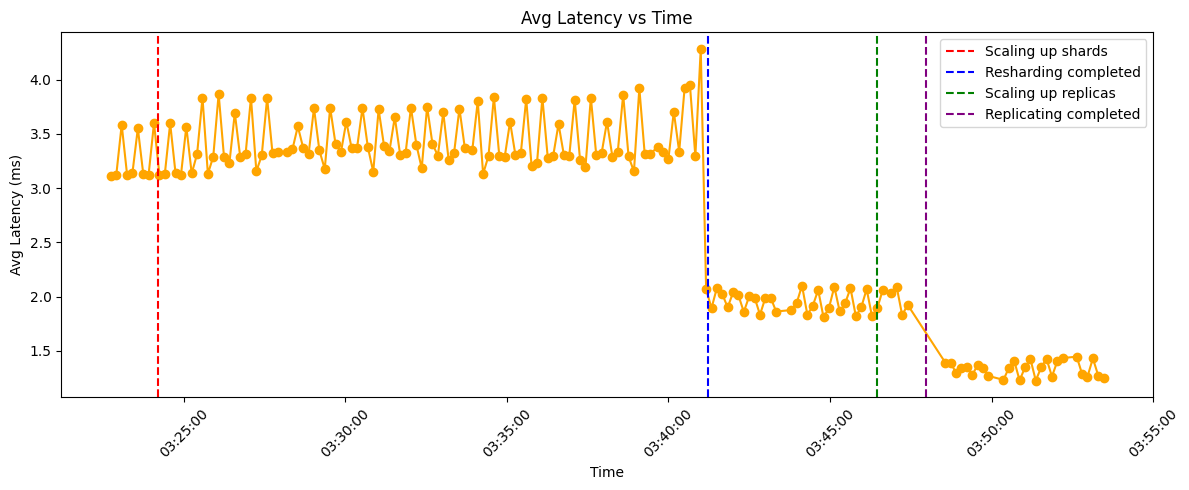

In [18]:
from pathlib import Path
import re
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

log_dir = Path('mongod_cpu_exp')
files = list(log_dir.glob('*.log'))
files.sort()

times = []
throughputs = []
latencies = []

for f in files:
    with f.open() as file:
        for line in file:
            if line.startswith('#OUTLIER'):
                continue
            match = re.search(r' (\d{2}:\d{2}:\d{2}).*? ([\d.]+) current ops/sec;.*Avg=([\d.]+)', line)
            if match:
                times.append(datetime.strptime(match.group(1), '%H:%M:%S'))
                throughputs.append(float(match.group(2)))
                latencies.append(float(match.group(3)) / 1000)

highlight_times = [
    (datetime.strptime('03:24:12', '%H:%M:%S'), "Scaling up shards", 'red'),
    (datetime.strptime('03:41:13', '%H:%M:%S'), "Resharding completed", 'blue'),
    (datetime.strptime('03:46:28', '%H:%M:%S'), "Scaling up replicas ", 'green'),
    (datetime.strptime('03:47:58', '%H:%M:%S'), "Replicating completed", 'purple'),
]

# Plot throughput vs time
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(times, throughputs, marker='o')
for ht, label, color in highlight_times:
    ax.axvline(x=ht, color=color, linestyle='--', label=label)
ax.set_xlabel('Time')
ax.set_ylabel('Throughput (ops/sec)')
ax.set_title('Throughput vs Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Plot latency vs time
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(times, latencies, marker='o', color='orange')
for ht, label, color in highlight_times:
    ax.axvline(x=ht, color=color, linestyle='--', label=label)
ax.set_xlabel('Time')
ax.set_ylabel('Avg Latency (ms)')
ax.set_title('Avg Latency vs Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Mongod Autoscaler - disk I/O-bounded

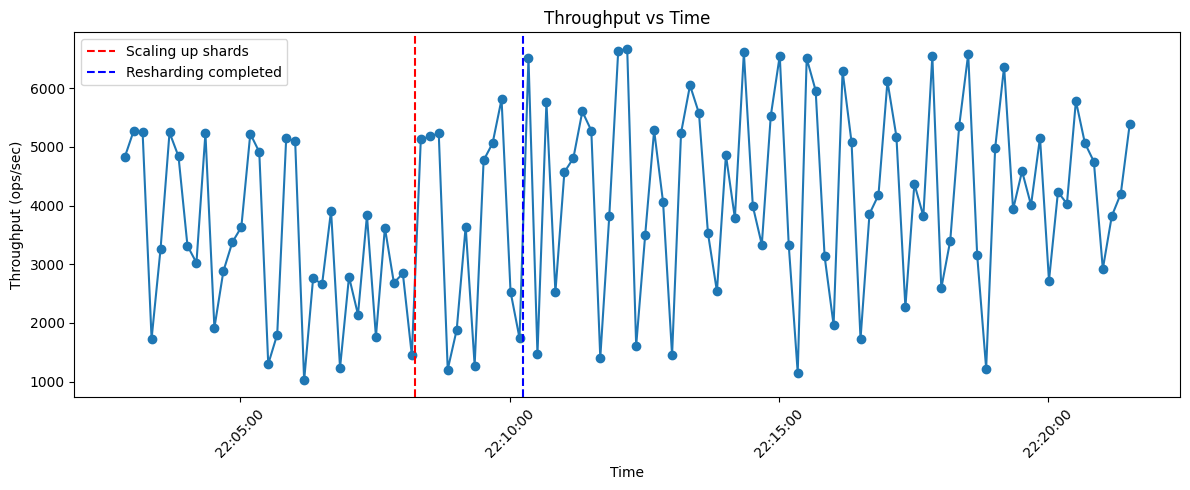

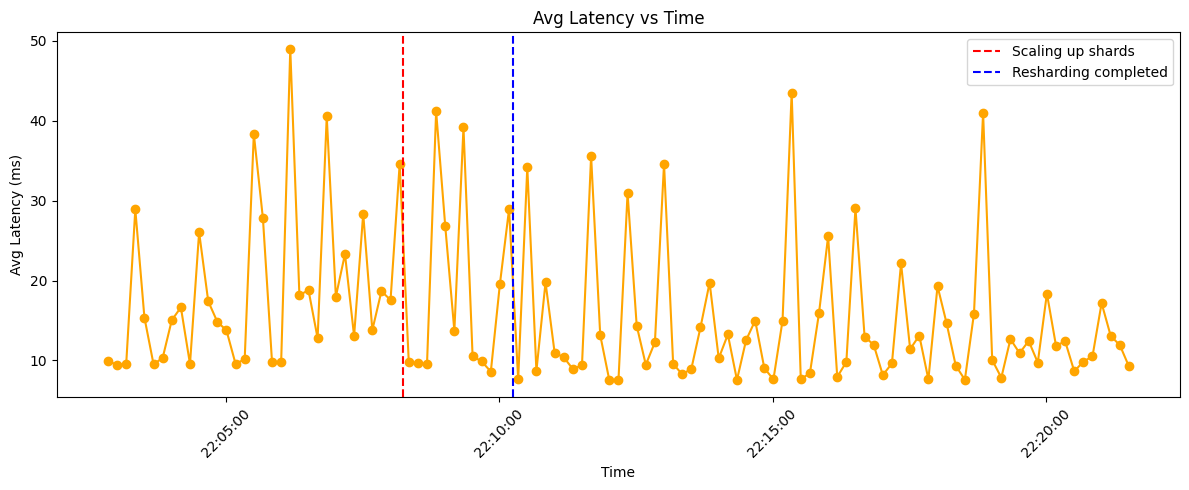

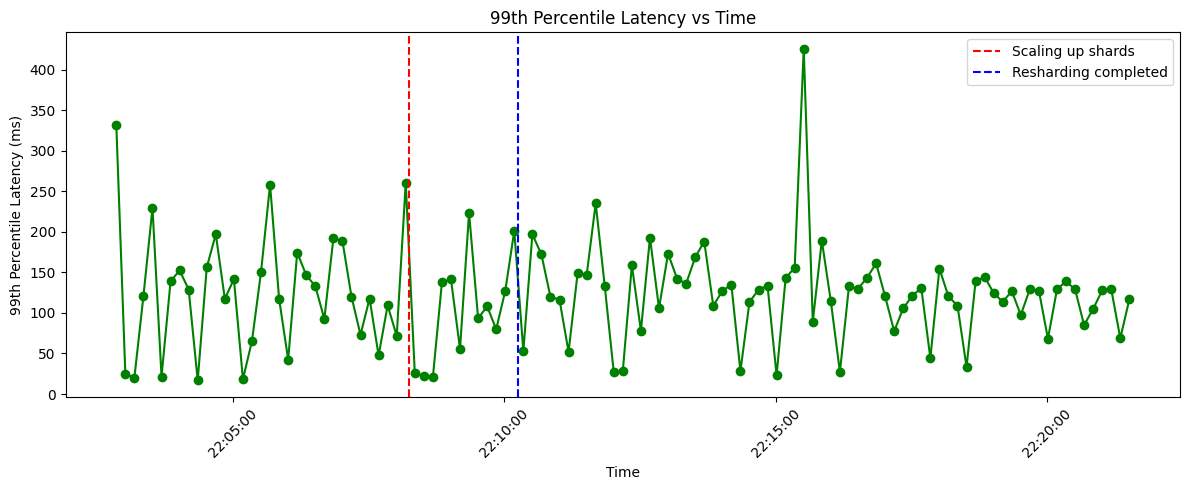

In [19]:
from pathlib import Path
import re
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

times = []
throughputs = []
latencies = []
latency_99s = []

with open('mongod_iowait_exp/run_50.log') as file:
    for line in file:
        if line.startswith('#OUTLIER'):
            continue
        match = re.search(r' (\d{2}:\d{2}:\d{2}).*? ([\d.]+) current ops/sec;.*Avg=([\d.]+),.*99=([\d.]+)', line)
        if match:
            times.append(datetime.strptime(match.group(1), '%H:%M:%S'))
            throughputs.append(float(match.group(2)))
            latencies.append(float(match.group(3)) / 1000)
            latency_99s.append(float(match.group(4)) / 1000)

highlight_times = [
    (datetime.strptime('22:08:15', '%H:%M:%S'), "Scaling up shards", 'red'),
    (datetime.strptime('22:10:15', '%H:%M:%S'), "Resharding completed", 'blue'),
]

# Plot throughput vs time
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(times, throughputs, marker='o')
for ht, label, color in highlight_times:
    ax.axvline(x=ht, color=color, linestyle='--', label=label)
ax.set_xlabel('Time')
ax.set_ylabel('Throughput (ops/sec)')
ax.set_title('Throughput vs Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Plot latency vs time
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(times, latencies, marker='o', color='orange')
for ht, label, color in highlight_times:
    ax.axvline(x=ht, color=color, linestyle='--', label=label)
ax.set_xlabel('Time')
ax.set_ylabel('Avg Latency (ms)')
ax.set_title('Avg Latency vs Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 99th percentile latency vs time
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(times, latency_99s, marker='o', color='green')
for ht, label, color in highlight_times:
    ax.axvline(x=ht, color=color, linestyle='--', label=label)
ax.set_xlabel('Time')
ax.set_ylabel('99th Percentile Latency (ms)')
ax.set_title('99th Percentile Latency vs Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()